In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                           mean_absolute_percentage_error)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Load the dataset
# Note: Make sure to upload the CSV file to your Colab environment first
df = pd.read_csv('energy_data_II.csv')

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
for i, col in enumerate(df.columns):
    print(f"{i+1:2d}. {col}")

print(f"\nDataset loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns")
print("\nFirst few rows:")
df.head()

Dataset Shape: (2926, 54)

Column Names:
 1. Country Name
 2. Country Code
 3. Years
 4. Access to clean fuels and technologies for cooking (% of population)
 5. Access to clean fuels and technologies for cooking, rural (% of rural population)
 6. Access to clean fuels and technologies for cooking, urban (% of urban population)
 7. Access to electricity (% of population)
 8. Access to electricity, rural (% of rural population)
 9. Access to electricity, urban (% of urban population)
10. Adjusted savings: energy depletion (% of GNI)
11. Alternative and nuclear energy (% of total energy use)
12. CO2 emissions (kt)
13. CO2 emissions (metric tons per capita)
14. CO2 emissions from electricity and heat production, total (% of total fuel combustion)
15. CO2 emissions from gaseous fuel consumption (% of total)
16. CO2 emissions from gaseous fuel consumption (kt)
17. CO2 emissions from liquid fuel consumption (% of total)
18. CO2 emissions from liquid fuel consumption (kt)
19. CO2 emissions fr

,Country Name,Country Code,Years,Access to clean fuels and technologies for cooking (% of population),"Access to clean fuels and technologies for cooking, rural (% of rural population)","Access to clean fuels and technologies for cooking, urban (% of urban population)",Access to electricity (% of population),"Access to electricity, rural (% of rural population)","Access to electricity, urban (% of urban population)",Adjusted savings: energy depletion (% of GNI),...,Population growth (annual %),"Population, female (% of total population)","Population, male","Population, male (% of total population)","Population, total",Public private partnerships investment in energy (current US$),Renewable electricity output (% of total electricity output),Renewable energy consumption (% of total final energy consumption),Time required to get electricity (days),Total greenhouse gas emissions (kt of CO2 equivalent)
0,Afghanistan,AFG,1990,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.202434,49.990753,5348387.0,50.009247,10694796.0,NaN,67.730496,23.00,NaN,11630.79506
1,Afghanistan,AFG,2000,6.70,1.1,30.5,4.446891,NaN,73.444473,NaN,...,1.443803,49.775111,9815442.0,50.224894,19542982.0,NaN,74.989094,44.99,NaN,14205.32527
2,Afghanistan,AFG,2013,24.30,8.9,75.8,68.040878,60.239198,92.248718,0.073924,...,3.466788,49.442103,15946572.0,50.557897,31541209.0,NaN,78.636408,16.86,114.0,30430.30008
3,Afghanistan,AFG,2014,25.70,9.9,77.6,89.500000,86.500512,98.700000,0.068797,...,3.657576,49.432135,16543889.0,50.567865,32716210.0,NaN,85.323549,18.93,114.0,31165.81580
4,Afghanistan,AFG,2015,27.25,10.9,78.9,71.500000,64.573354,92.500000,0.050390,...,3.121341,49.423184,17071446.0,50.576819,33753499.0,NaN,86.050111,17.53,114.0,31619.07371


CO2/Emission related columns found:
- CO2 emissions (kt)
- CO2 emissions (metric tons per capita)
- CO2 emissions from electricity and heat production, total (% of total fuel combustion)
- CO2 emissions from gaseous fuel consumption (% of total)
- CO2 emissions from gaseous fuel consumption (kt)
- CO2 emissions from liquid fuel consumption (% of total)
- CO2 emissions from liquid fuel consumption (kt)
- CO2 emissions from manufacturing industries and construction (% of total fuel combustion)
- CO2 emissions from other sectors, excluding residential buildings and commercial and public services (% of total fuel combustion)
- CO2 emissions from residential buildings and commercial and public services (% of total fuel combustion)
- CO2 emissions from solid fuel consumption (% of total)
- CO2 emissions from solid fuel consumption (kt)
- CO2 emissions from transport (% of total fuel combustion)
- CO2 intensity (kg per kg of oil equivalent energy use)
- Total greenhouse gas emissions (kt of C

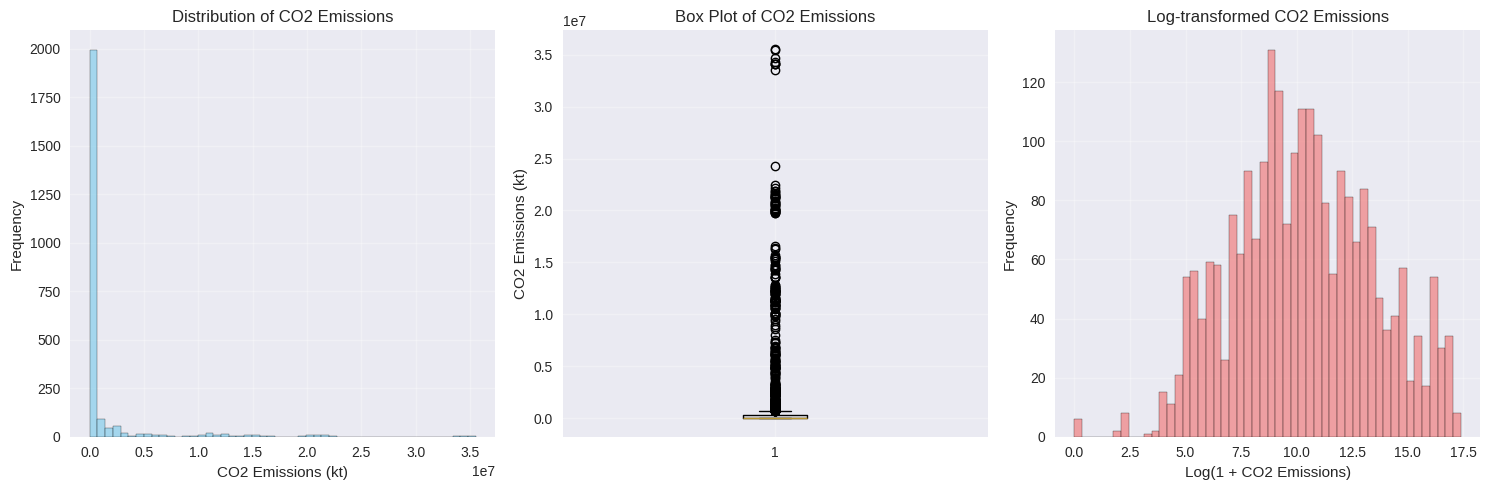

In [4]:
# Check if CO2 emissions column exists and analyze it
co2_columns = [col for col in df.columns if 'CO2' in col.upper() or 'EMISSION' in col.upper()]
print("CO2/Emission related columns found:")
for col in co2_columns:
    print(f"- {col}")

# Use the CO2 emissions column
target_column = None
for col in df.columns:
    if 'CO2' in col and 'kt' in col:
        target_column = col
        break

if target_column is None:
    # If exact match not found, use the first CO2 related column
    target_column = co2_columns[0] if co2_columns else df.select_dtypes(include=[np.number]).columns[2]

print(f"\nSelected target variable: {target_column}")

# Analyze the target variable
print(f"\nCO2 Emissions Analysis:")
print(f"Data type: {df[target_column].dtype}")
print(f"Non-null values: {df[target_column].count()}")
print(f"Missing values: {df[target_column].isnull().sum()}")
print(f"Range: {df[target_column].min():.2f} to {df[target_column].max():.2f}")
print(f"Mean: {df[target_column].mean():.2f}")
print(f"Median: {df[target_column].median():.2f}")
print(f"Standard deviation: {df[target_column].std():.2f}")

# Visualize target distribution
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(df[target_column].dropna(), bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribution of CO2 Emissions')
plt.xlabel('CO2 Emissions (kt)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.boxplot(df[target_column].dropna())
plt.title('Box Plot of CO2 Emissions')
plt.ylabel('CO2 Emissions (kt)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
# Log scale for better visualization if values are very large
log_values = np.log1p(df[target_column].dropna())
plt.hist(log_values, bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
plt.title('Log-transformed CO2 Emissions')
plt.xlabel('Log(1 + CO2 Emissions)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# Create a copy for processing
df_clean = df.copy()

print("Initial dataset info:")
print(f"Shape: {df_clean.shape}")
print(f"Total missing values: {df_clean.isnull().sum().sum()}")

# Handle missing values in target variable
print(f"\nTarget variable ({target_column}) missing values: {df_clean[target_column].isnull().sum()}")

# Remove rows where target variable is missing
df_clean = df_clean.dropna(subset=[target_column])
print(f"After removing missing target values: {df_clean.shape}")

# Handle missing values in other columns
numerical_cols = df_clean.select_dtypes(include=[np.number]).columns
categorical_cols = df_clean.select_dtypes(include=['object']).columns

print(f"\nNumerical columns: {len(numerical_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

# Fill numerical missing values with median
for col in numerical_cols:
    if col != target_column:
        missing_count = df_clean[col].isnull().sum()
        if missing_count > 0:
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())
            print(f"Filled {missing_count} missing values in {col}")

# Handle categorical variables
label_encoders = {}
for col in categorical_cols:
    if col in ['Entity', 'Country']:  # Keep country names for reference
        continue
    le = LabelEncoder()
    # Fill missing categorical values with mode
    mode_value = df_clean[col].mode()[0] if not df_clean[col].mode().empty else 'Unknown'
    df_clean[col] = df_clean[col].fillna(mode_value)
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded categorical column: {col}")

print(f"\nFinal shape after cleaning: {df_clean.shape}")
print(f"Remaining missing values: {df_clean.isnull().sum().sum()}")

Initial dataset info:
Shape: (2926, 54)
Total missing values: 65272

Target variable (CO2 emissions (kt)) missing values: 537
After removing missing target values: (2389, 54)

Numerical columns: 52
Categorical columns: 2
Filled 274 missing values in Access to clean fuels and technologies for cooking (% of population)
Filled 274 missing values in Access to clean fuels and technologies for cooking, rural (% of rural population)
Filled 274 missing values in Access to clean fuels and technologies for cooking, urban (% of urban population)
Filled 158 missing values in Access to electricity (% of population)
Filled 261 missing values in Access to electricity, rural (% of rural population)
Filled 181 missing values in Access to electricity, urban (% of urban population)
Filled 128 missing values in Adjusted savings: energy depletion (% of GNI)
Filled 1605 missing values in Alternative and nuclear energy (% of total energy use)
Filled 1658 missing values in CO2 emissions from electricity and h

In [6]:
# Prepare features (exclude target variable and non-predictive columns)
exclude_cols = [target_column, 'Entity', 'Country']
exclude_cols = [col for col in exclude_cols if col in df_clean.columns]

feature_columns = [col for col in df_clean.columns if col not in exclude_cols]
print(f"Selected {len(feature_columns)} features for modeling:")
for i, col in enumerate(feature_columns, 1):
    print(f"{i:2d}. {col}")

# Create feature matrix and target vector
X = df_clean[feature_columns].select_dtypes(include=[np.number])
y = df_clean[target_column]

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

# Remove any remaining NaN values
mask = ~(X.isnull().any(axis=1) | y.isnull())
X = X[mask]
y = y[mask]

print(f"After removing any remaining NaN values:")
print(f"Features: {X.shape}, Target: {y.shape}")

# Check for infinite values
inf_mask = np.isinf(X).any(axis=1) | np.isinf(y)
if inf_mask.sum() > 0:
    print(f"Removing {inf_mask.sum()} rows with infinite values")
    X = X[~inf_mask]
    y = y[~inf_mask]

print(f"Final dataset: Features {X.shape}, Target {y.shape}")
print(f"Target range: {y.min():.2f} to {y.max():.2f}")

Selected 53 features for modeling:
 1. Country Name
 2. Country Code
 3. Years
 4. Access to clean fuels and technologies for cooking (% of population)
 5. Access to clean fuels and technologies for cooking, rural (% of rural population)
 6. Access to clean fuels and technologies for cooking, urban (% of urban population)
 7. Access to electricity (% of population)
 8. Access to electricity, rural (% of rural population)
 9. Access to electricity, urban (% of urban population)
10. Adjusted savings: energy depletion (% of GNI)
11. Alternative and nuclear energy (% of total energy use)
12. CO2 emissions (metric tons per capita)
13. CO2 emissions from electricity and heat production, total (% of total fuel combustion)
14. CO2 emissions from gaseous fuel consumption (% of total)
15. CO2 emissions from gaseous fuel consumption (kt)
16. CO2 emissions from liquid fuel consumption (% of total)
17. CO2 emissions from liquid fuel consumption (kt)
18. CO2 emissions from manufacturing industries a

In [7]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"Training set: X={X_train.shape}, y={y_train.shape}")
print(f"Test set: X={X_test.shape}, y={y_test.shape}")

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nFeatures scaled successfully")
print(f"Training features mean: {X_train_scaled.mean():.6f}")
print(f"Training features std: {X_train_scaled.std():.6f}")
print(f"Test features mean: {X_test_scaled.mean():.6f}")
print(f"Test features std: {X_test_scaled.std():.6f}")

# Target variable statistics
print(f"\nTarget variable statistics:")
print(f"Training - Mean: {y_train.mean():.2f}, Std: {y_train.std():.2f}")
print(f"Test - Mean: {y_test.mean():.2f}, Std: {y_test.std():.2f}")

Training set: X=(1911, 53), y=(1911,)
Test set: X=(478, 53), y=(478,)

Features scaled successfully
Training features mean: -0.000000
Training features std: 1.000000
Test features mean: -0.004003
Test features std: 1.064708

Target variable statistics:
Training - Mean: 1228121.23, Std: 3960177.35
Test - Mean: 1108643.33, Std: 3775957.17


In [8]:
# Create and train base Random Forest model
print("Training Base Random Forest Model...")
rf_base = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_base.fit(X_train_scaled, y_train)

# Make predictions
y_pred_rf = rf_base.predict(X_test_scaled)

print("Base Random Forest trained successfully!")
print(f"Predictions range: {y_pred_rf.min():.2f} to {y_pred_rf.max():.2f}")

Training Base Random Forest Model...
Base Random Forest trained successfully!
Predictions range: 9.72 to 24507537.23


In [10]:
# Create Bagging ensemble with Random Forest as base estimator
print("Creating Bagging Ensemble with Random Forest...")

bagging_rf = BaggingRegressor(
    estimator=RandomForestRegressor(
        n_estimators=50,
        max_depth=12,
        min_samples_split=5,
        random_state=42,
        n_jobs=1
    ),
    n_estimators=10,  # Number of Random Forest models in the ensemble
    max_samples=0.8,  # Use 80% of samples for each model
    max_features=0.8,  # Use 80% of features for each model
    bootstrap=True,
    bootstrap_features=True,
    random_state=42,
    n_jobs=-1
)

# Train the bagging model
print("Training Bagging Model...")
bagging_rf.fit(X_train_scaled, y_train)

# Make predictions
y_pred_bagging = bagging_rf.predict(X_test_scaled)

print("Bagging model trained successfully!")
print(f"Predictions range: {y_pred_bagging.min():.2f} to {y_pred_bagging.max():.2f}")

Creating Bagging Ensemble with Random Forest...
Training Bagging Model...
Bagging model trained successfully!
Predictions range: 646.75 to 25316814.57


In [9]:
# Create advanced bagging ensemble with optimized parameters
print("Creating Advanced Bagging Model...")

advanced_bagging = BaggingRegressor(
    estimator=RandomForestRegressor(
        n_estimators=30,
        max_depth=10,
        min_samples_split=8,
        min_samples_leaf=3,
        max_features='sqrt',
        random_state=42
    ),
    n_estimators=15,
    max_samples=0.75,
    max_features=0.85,
    bootstrap=True,
    bootstrap_features=True,
    random_state=42,
    n_jobs=-1
)

# Train the advanced model
print("Training Advanced Bagging Model...")
advanced_bagging.fit(X_train_scaled, y_train)

# Make predictions
y_pred_advanced = advanced_bagging.predict(X_test_scaled)

print("Advanced Bagging model trained successfully!")
print(f"Predictions range: {y_pred_advanced.min():.2f} to {y_pred_advanced.max():.2f}")

Creating Advanced Bagging Model...
Training Advanced Bagging Model...
Advanced Bagging model trained successfully!
Predictions range: 4102.94 to 21250105.59


In [11]:
def comprehensive_evaluation(y_true, y_pred, model_name):
    """
    Comprehensive evaluation of regression model performance
    """
    print(f"\n{'='*60}")
    print(f"EVALUATION RESULTS FOR {model_name.upper()}")
    print(f"{'='*60}")

    # Basic regression metrics
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    # Additional metrics
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    # Residual analysis
    residuals = y_true - y_pred
    residual_mean = np.mean(residuals)
    residual_std = np.std(residuals)

    # Noise estimation (standard deviation of residuals)
    noise = residual_std

    # Accuracy (custom metric for regression: percentage of predictions within tolerance)
    tolerance = 0.1 * np.std(y_true)  # 10% of target standard deviation
    accuracy = np.mean(np.abs(residuals) <= tolerance) * 100

    print(f"Mean Squared Error (MSE):     {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE):    {mae:.4f}")
    print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
    print(f"R² Score:                     {r2:.4f}")
    print(f"Custom Accuracy:              {accuracy:.2f}%")
    print(f"Noise (Residual Std):         {noise:.4f}")
    print(f"Residual Mean:                {residual_mean:.4f}")

    # Error categorization
    small_errors = np.sum(np.abs(residuals) < tolerance)
    medium_errors = np.sum((np.abs(residuals) >= tolerance) & (np.abs(residuals) < 2*tolerance))
    large_errors = np.sum(np.abs(residuals) >= 2*tolerance)

    print(f"\nError Distribution:")
    print(f"Small errors (< {tolerance:.2f}):  {small_errors} ({small_errors/len(residuals)*100:.1f}%)")
    print(f"Medium errors:                     {medium_errors} ({medium_errors/len(residuals)*100:.1f}%)")
    print(f"Large errors (> {2*tolerance:.2f}): {large_errors} ({large_errors/len(residuals)*100:.1f}%)")

    return {
        'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2,
        'MAPE': mape, 'Accuracy': accuracy, 'Noise': noise,
        'Residuals': residuals
    }

# Evaluate all models
rf_results = comprehensive_evaluation(y_test, y_pred_rf, "Random Forest")
bagging_results = comprehensive_evaluation(y_test, y_pred_bagging, "Bagging Random Forest")
advanced_results = comprehensive_evaluation(y_test, y_pred_advanced, "Advanced Bagging")


EVALUATION RESULTS FOR RANDOM FOREST
Mean Squared Error (MSE):     51092451378.5191
Root Mean Squared Error (RMSE): 226036.3939
Mean Absolute Error (MAE):    35164.8999
Mean Absolute Percentage Error (MAPE): 9154071013577210.00%
R² Score:                     0.9964
Custom Accuracy:              97.70%
Noise (Residual Std):         225798.6238
Residual Mean:                -10364.9825

Error Distribution:
Small errors (< 377200.54):  467 (97.7%)
Medium errors:                     8 (1.7%)
Large errors (> 754401.07): 3 (0.6%)

EVALUATION RESULTS FOR BAGGING RANDOM FOREST
Mean Squared Error (MSE):     63963173023.3837
Root Mean Squared Error (RMSE): 252909.4166
Mean Absolute Error (MAE):    57263.3071
Mean Absolute Percentage Error (MAPE): 609353126361996160.00%
R² Score:                     0.9955
Custom Accuracy:              96.03%
Noise (Residual Std):         252898.4758
Residual Mean:                -2352.4357

Error Distribution:
Small errors (< 377200.54):  459 (96.0%)
Medium err

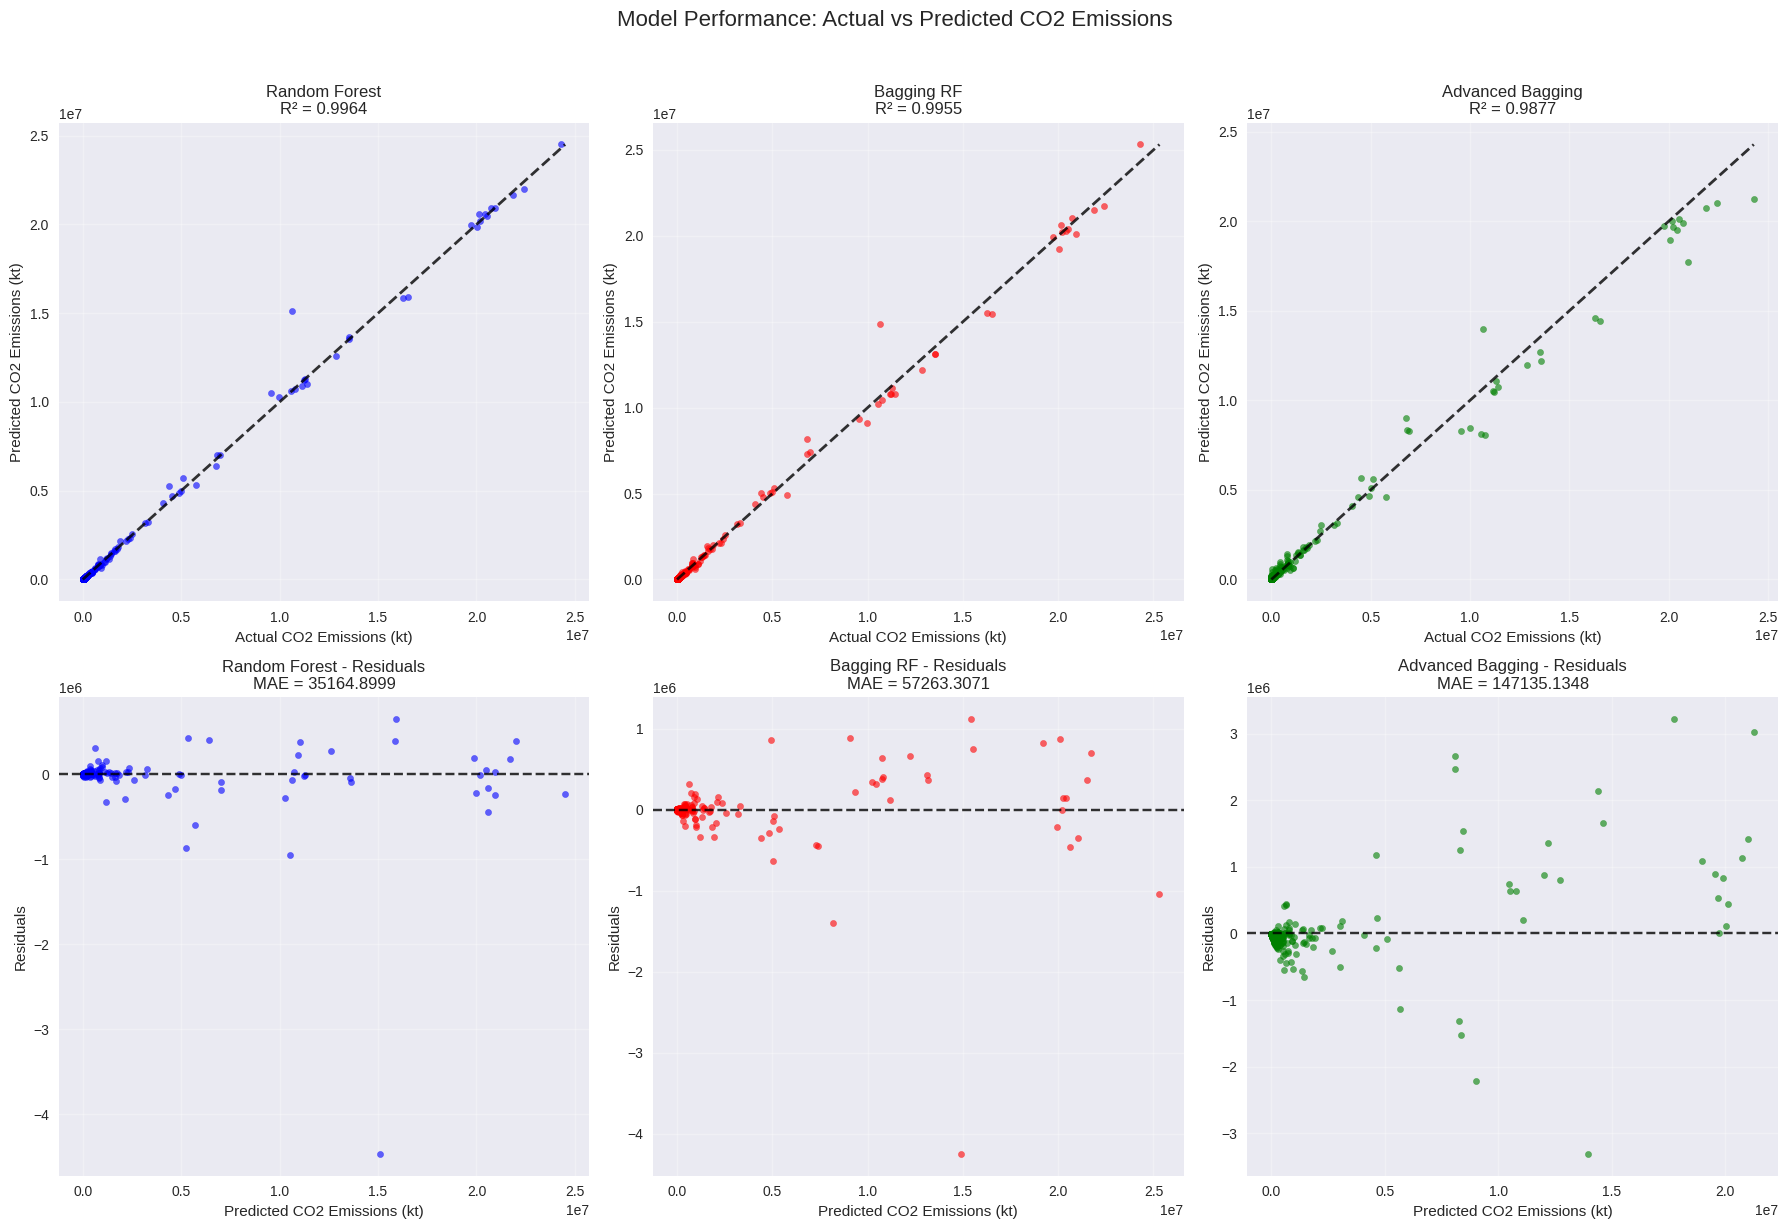

In [12]:
# Create comprehensive actual vs predicted plots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Model Performance: Actual vs Predicted CO2 Emissions', fontsize=16, y=1.02)

models_data = [
    ("Random Forest", y_pred_rf, rf_results, 'blue'),
    ("Bagging RF", y_pred_bagging, bagging_results, 'red'),
    ("Advanced Bagging", y_pred_advanced, advanced_results, 'green')
]

# Plot 1: Actual vs Predicted scatter plots
for i, (name, pred, results, color) in enumerate(models_data):
    ax = axes[0, i]
    ax.scatter(y_test, pred, alpha=0.6, color=color, s=20)

    # Perfect prediction line
    min_val, max_val = min(y_test.min(), pred.min()), max(y_test.max(), pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, alpha=0.8)

    ax.set_xlabel('Actual CO2 Emissions (kt)')
    ax.set_ylabel('Predicted CO2 Emissions (kt)')
    ax.set_title(f'{name}\nR² = {results["R2"]:.4f}')
    ax.grid(True, alpha=0.3)

# Plot 2: Residual plots
for i, (name, pred, results, color) in enumerate(models_data):
    ax = axes[1, i]
    residuals = results['Residuals']
    ax.scatter(pred, residuals, alpha=0.6, color=color, s=20)
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.8)
    ax.set_xlabel('Predicted CO2 Emissions (kt)')
    ax.set_ylabel('Residuals')
    ax.set_title(f'{name} - Residuals\nMAE = {results["MAE"]:.4f}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

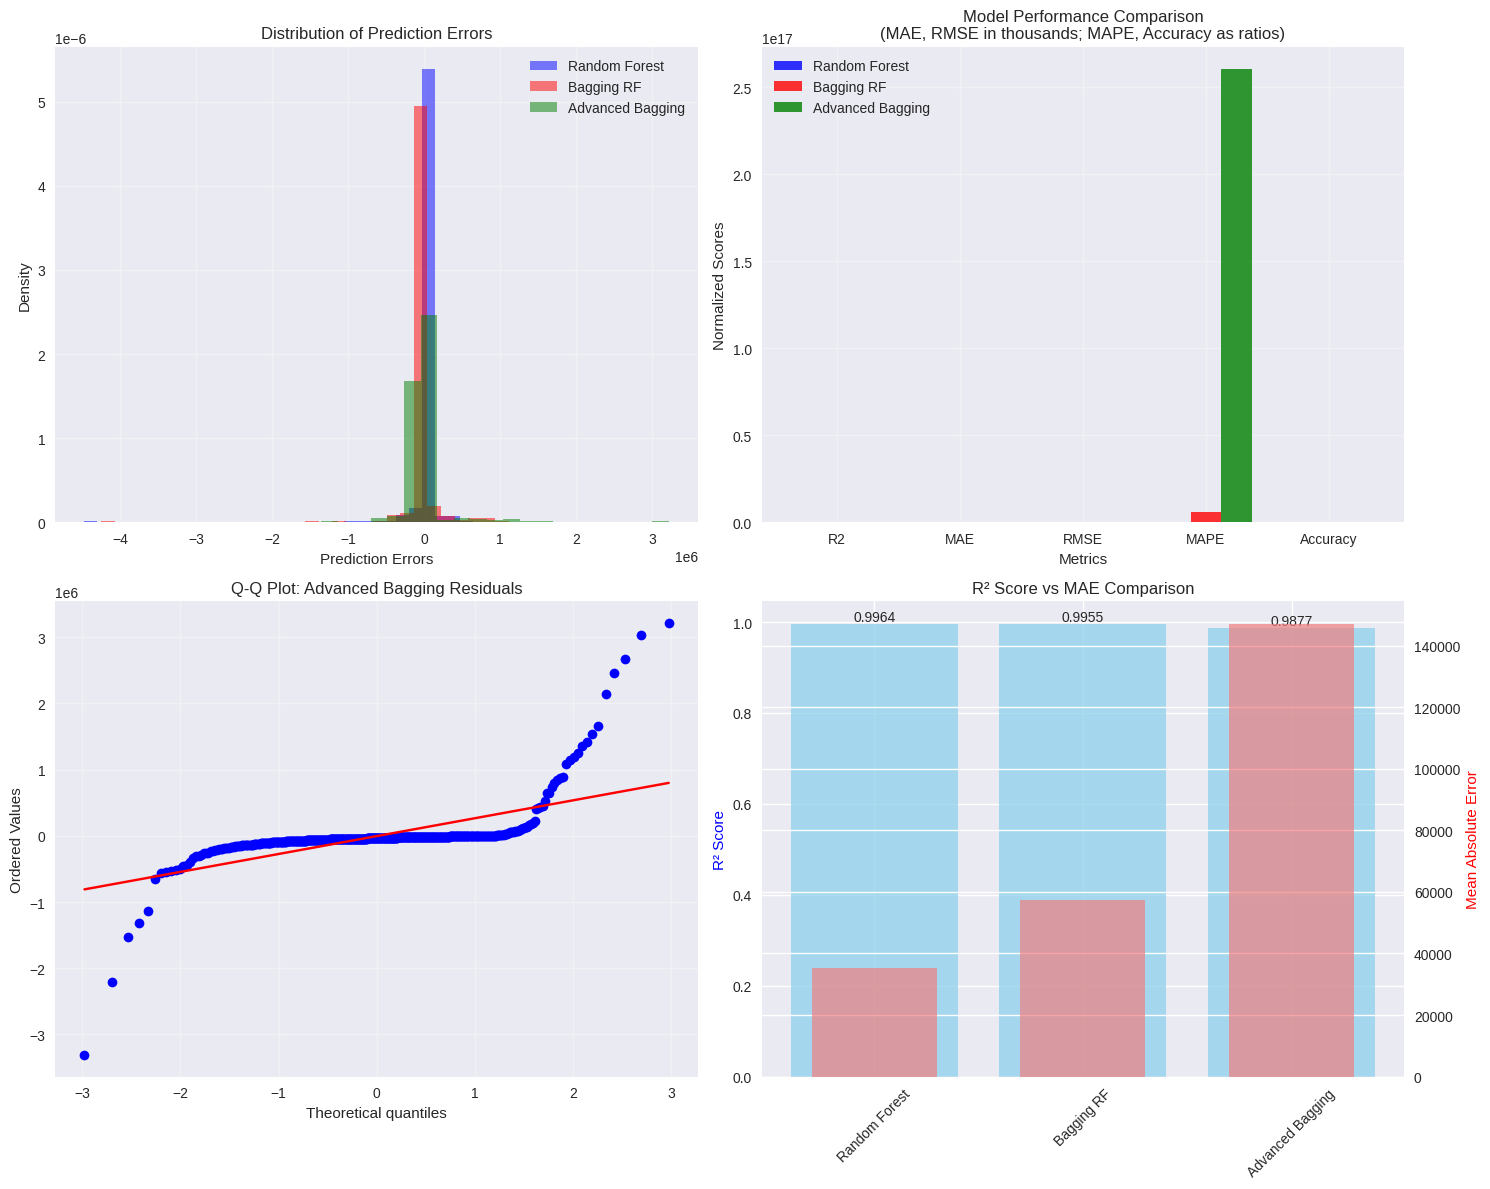

In [13]:
# Create detailed error analysis plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Error distribution histograms
ax = axes[0, 0]
for name, pred, results, color in models_data:
    residuals = results['Residuals']
    ax.hist(residuals, bins=30, alpha=0.5, label=name, color=color, density=True)
ax.set_xlabel('Prediction Errors')
ax.set_ylabel('Density')
ax.set_title('Distribution of Prediction Errors')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Performance metrics comparison
ax = axes[0, 1]
metrics = ['R2', 'MAE', 'RMSE', 'MAPE', 'Accuracy']
x_pos = np.arange(len(metrics))

rf_scores = [rf_results['R2'], rf_results['MAE']/1000, rf_results['RMSE']/1000,
             rf_results['MAPE']/100, rf_results['Accuracy']/100]
bagging_scores = [bagging_results['R2'], bagging_results['MAE']/1000, bagging_results['RMSE']/1000,
                  bagging_results['MAPE']/100, bagging_results['Accuracy']/100]
advanced_scores = [advanced_results['R2'], advanced_results['MAE']/1000, advanced_results['RMSE']/1000,
                   advanced_results['MAPE']/100, advanced_results['Accuracy']/100]

width = 0.25
ax.bar(x_pos - width, rf_scores, width, label='Random Forest', alpha=0.8, color='blue')
ax.bar(x_pos, bagging_scores, width, label='Bagging RF', alpha=0.8, color='red')
ax.bar(x_pos + width, advanced_scores, width, label='Advanced Bagging', alpha=0.8, color='green')

ax.set_xlabel('Metrics')
ax.set_ylabel('Normalized Scores')
ax.set_title('Model Performance Comparison\n(MAE, RMSE in thousands; MAPE, Accuracy as ratios)')
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Q-Q plot for residuals (normality check)
ax = axes[1, 0]
stats.probplot(advanced_results['Residuals'], dist="norm", plot=ax)
ax.set_title('Q-Q Plot: Advanced Bagging Residuals')
ax.grid(True, alpha=0.3)

# 4. Prediction vs Target Range
ax = axes[1, 1]
models_names = [name for name, _, _, _ in models_data]
r2_scores = [results['R2'] for _, _, results, _ in models_data]
mae_scores = [results['MAE'] for _, _, results, _ in models_data]

ax2 = ax.twinx()
bars1 = ax.bar(models_names, r2_scores, alpha=0.7, color='skyblue', label='R² Score')
bars2 = ax2.bar(models_names, mae_scores, alpha=0.7, color='lightcoral', width=0.6, label='MAE')

ax.set_ylabel('R² Score', color='blue')
ax2.set_ylabel('Mean Absolute Error', color='red')
ax.set_title('R² Score vs MAE Comparison')
ax.tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar, score in zip(bars1, r2_scores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{score:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

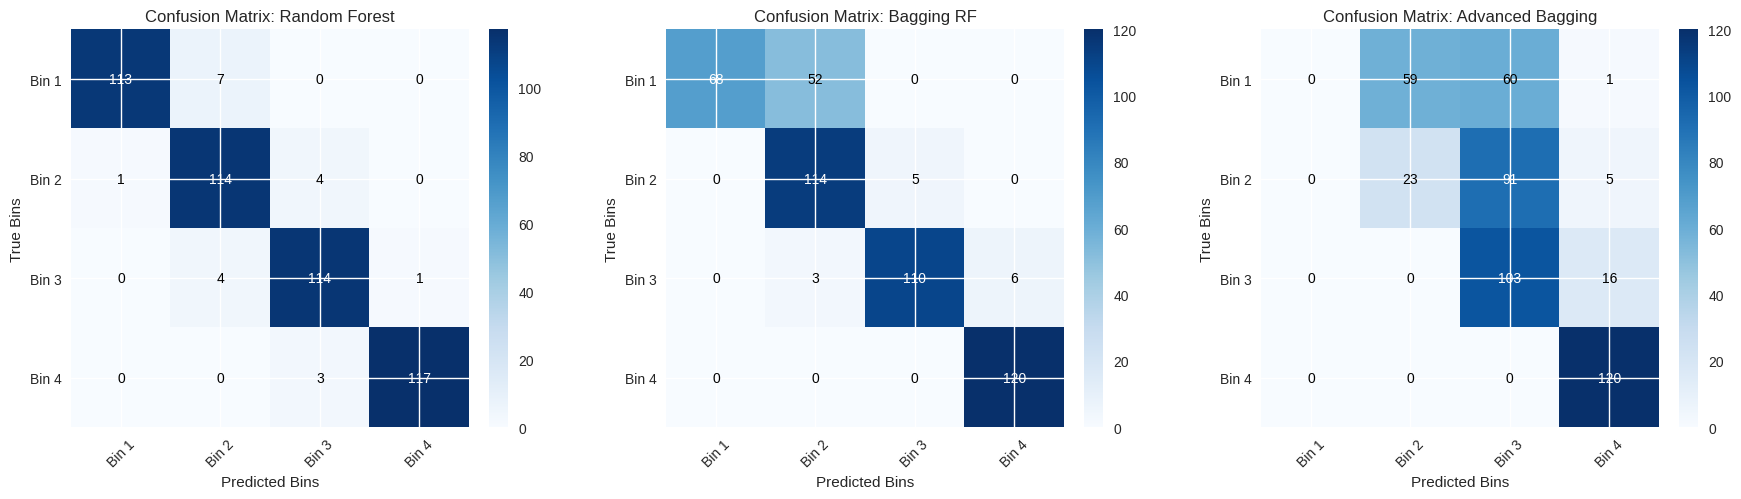

Binned Prediction Accuracy (4 bins):
Random Forest: 95.82%
Bagging RF: 86.19%
Advanced Bagging: 51.46%


In [14]:
# Create confusion matrix for regression by binning the predictions
# This gives us a classification-like view of regression performance

def create_regression_confusion_matrix(y_true, y_pred, n_bins=5):
    """
    Create a confusion matrix for regression by binning values
    """
    # Create bins based on quantiles of true values
    bin_edges = np.quantile(y_true, np.linspace(0, 1, n_bins + 1))
    bin_edges[-1] += 0.01  # Adjust last edge to include maximum value

    # Create labels for bins
    bin_labels = [f'Bin {i+1}\n({bin_edges[i]:.0f}-{bin_edges[i+1]:.0f})'
                  for i in range(n_bins)]

    # Assign true and predicted values to bins
    y_true_binned = np.digitize(y_true, bin_edges) - 1
    y_pred_binned = np.digitize(y_pred, bin_edges) - 1

    # Handle edge cases
    y_true_binned = np.clip(y_true_binned, 0, n_bins - 1)
    y_pred_binned = np.clip(y_pred_binned, 0, n_bins - 1)

    # Create confusion matrix
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_true_binned, y_pred_binned)

    return cm, bin_labels

# Create confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, pred, results, color) in enumerate(models_data):
    cm, bin_labels = create_regression_confusion_matrix(y_test, pred, n_bins=4)

    ax = axes[i]
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(f'Confusion Matrix: {name}')

    # Add colorbar
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Add text annotations
    thresh = cm.max() / 2.
    for row in range(cm.shape[0]):
        for col in range(cm.shape[1]):
            ax.text(col, row, format(cm[row, col], 'd'),
                   ha="center", va="center",
                   color="white" if cm[row, col] > thresh else "black")

    # Set labels
    tick_marks = np.arange(len(bin_labels))
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels([label.split('\n')[0] for label in bin_labels], rotation=45)
    ax.set_yticklabels([label.split('\n')[0] for label in bin_labels])
    ax.set_ylabel('True Bins')
    ax.set_xlabel('Predicted Bins')

plt.tight_layout()
plt.show()

# Calculate accuracy for binned predictions
print("Binned Prediction Accuracy (4 bins):")
for name, pred, results, color in models_data:
    cm, _ = create_regression_confusion_matrix(y_test, pred, n_bins=4)
    accuracy = np.trace(cm) / np.sum(cm) * 100
    print(f"{name}: {accuracy:.2f}%")

=== ROC Curve Analysis for Bagging Models ===
Converting regression problem to binary classification...
Classification Threshold (Median): 21392.75
Class distribution: [239 239] (0: Low, 1: High emissions)


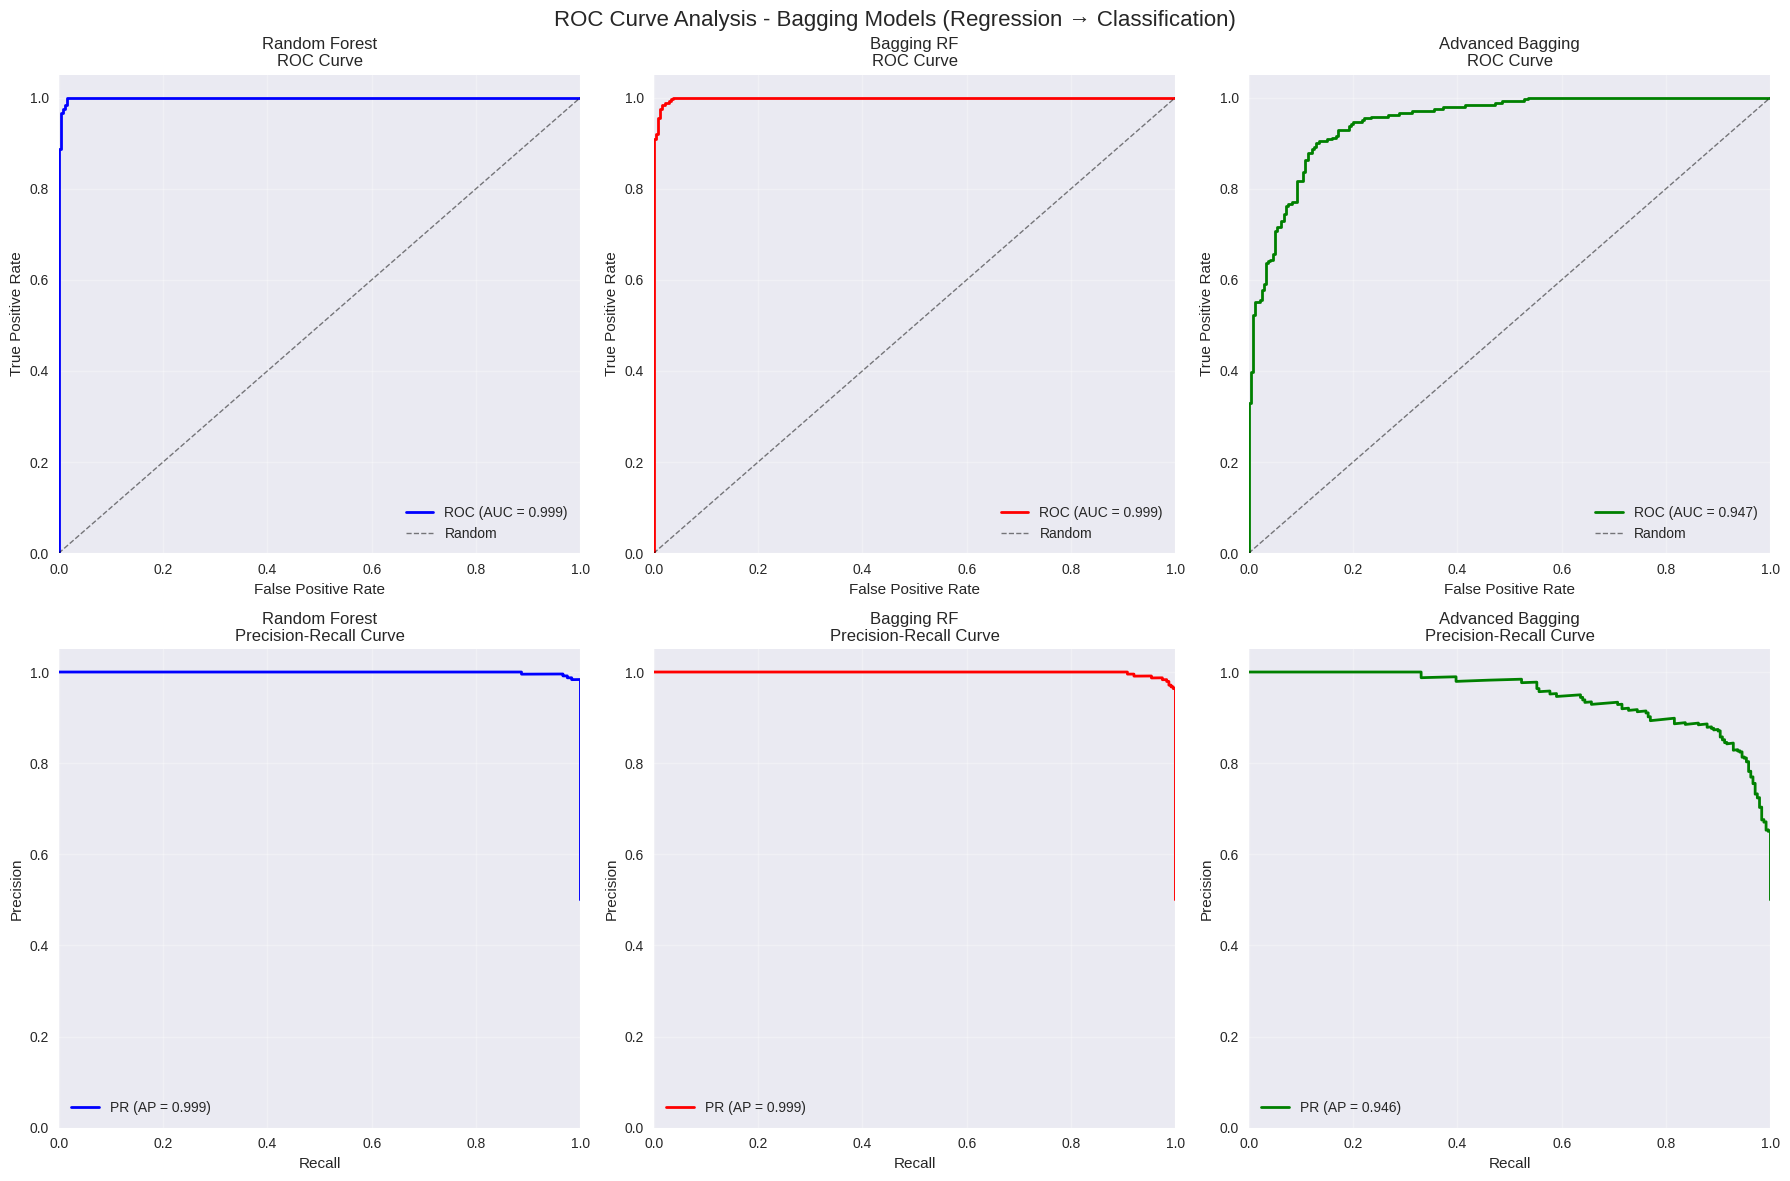


=== ROC Analysis Results ===
Classification based on median threshold: 21392.75
------------------------------------------------------------
Random Forest:
  AUC Score: 0.9992 (Excellent)
  Average Precision: 0.9992

Bagging RF:
  AUC Score: 0.9988 (Excellent)
  Average Precision: 0.9987

Advanced Bagging:
  AUC Score: 0.9468 (Excellent)
  Average Precision: 0.9462



In [15]:
# CELL 14: ROC Curve Analysis by Converting Regression to Classification
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
import seaborn as sns

def regression_to_classification_roc(y_true, predictions_dict, threshold_method='median'):
    """
    Convert regression predictions to binary classification and create ROC curves

    Parameters:
    - y_true: True target values
    - predictions_dict: Dictionary with model names as keys and predictions as values
    - threshold_method: 'median', 'mean', or 'quantile' for creating binary classes
    """
    print("=== ROC Curve Analysis for Bagging Models ===")
    print("Converting regression problem to binary classification...")

    # Create binary labels based on threshold
    if threshold_method == 'median':
        threshold = np.median(y_true)
        threshold_name = "Median"
    elif threshold_method == 'mean':
        threshold = np.mean(y_true)
        threshold_name = "Mean"
    elif threshold_method == 'quantile':
        threshold = np.quantile(y_true, 0.75)  # 75th percentile
        threshold_name = "75th Percentile"

    # Convert to binary: 1 if above threshold, 0 if below
    y_binary = (y_true > threshold).astype(int)

    print(f"Classification Threshold ({threshold_name}): {threshold:.2f}")
    print(f"Class distribution: {np.bincount(y_binary)} (0: Low, 1: High emissions)")

    # Convert predictions to binary classification scores
    # Use the continuous predictions as probability scores
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('ROC Curve Analysis - Bagging Models (Regression → Classification)', fontsize=16)

    colors = ['blue', 'red', 'green']
    results = {}

    # Calculate ROC curves for each model
    for i, (model_name, y_pred) in enumerate(predictions_dict.items()):
        # Use predictions as scores (higher prediction = higher probability of high emissions)
        y_scores = y_pred

        # Calculate ROC curve
        fpr, tpr, thresholds = roc_curve(y_binary, y_scores)
        auc_score = roc_auc_score(y_binary, y_scores)

        # Calculate Precision-Recall curve
        precision, recall, pr_thresholds = precision_recall_curve(y_binary, y_scores)
        ap_score = average_precision_score(y_binary, y_scores)

        results[model_name] = {
            'fpr': fpr, 'tpr': tpr, 'auc': auc_score,
            'precision': precision, 'recall': recall, 'ap': ap_score,
            'y_scores': y_scores
        }

        color = colors[i % len(colors)]

        # Plot ROC curve
        axes[0, i].plot(fpr, tpr, color=color, lw=2,
                       label=f'ROC (AUC = {auc_score:.3f})')
        axes[0, i].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random')
        axes[0, i].set_xlim([0.0, 1.0])
        axes[0, i].set_ylim([0.0, 1.05])
        axes[0, i].set_xlabel('False Positive Rate')
        axes[0, i].set_ylabel('True Positive Rate')
        axes[0, i].set_title(f'{model_name}\nROC Curve')
        axes[0, i].legend(loc="lower right")
        axes[0, i].grid(True, alpha=0.3)

        # Plot Precision-Recall curve
        axes[1, i].plot(recall, precision, color=color, lw=2,
                       label=f'PR (AP = {ap_score:.3f})')
        axes[1, i].set_xlim([0.0, 1.0])
        axes[1, i].set_ylim([0.0, 1.05])
        axes[1, i].set_xlabel('Recall')
        axes[1, i].set_ylabel('Precision')
        axes[1, i].set_title(f'{model_name}\nPrecision-Recall Curve')
        axes[1, i].legend(loc="lower left")
        axes[1, i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print results summary
    print(f"\n=== ROC Analysis Results ===")
    print(f"Classification based on {threshold_name.lower()} threshold: {threshold:.2f}")
    print("-" * 60)

    for model_name, result in results.items():
        auc_score = result['auc']
        ap_score = result['ap']

        if auc_score >= 0.9:
            performance = "Excellent"
        elif auc_score >= 0.8:
            performance = "Good"
        elif auc_score >= 0.7:
            performance = "Fair"
        elif auc_score >= 0.6:
            performance = "Poor"
        else:
            performance = "Very Poor"

        print(f"{model_name}:")
        print(f"  AUC Score: {auc_score:.4f} ({performance})")
        print(f"  Average Precision: {ap_score:.4f}")
        print()

    return results, y_binary, threshold

# Prepare predictions dictionary
predictions_dict = {
    'Random Forest': y_pred_rf,
    'Bagging RF': y_pred_bagging,
    'Advanced Bagging': y_pred_advanced
}

# Generate ROC analysis
roc_results, y_binary, threshold = regression_to_classification_roc(
    y_test, predictions_dict, threshold_method='median'
)


=== Multi-Threshold ROC Analysis ===


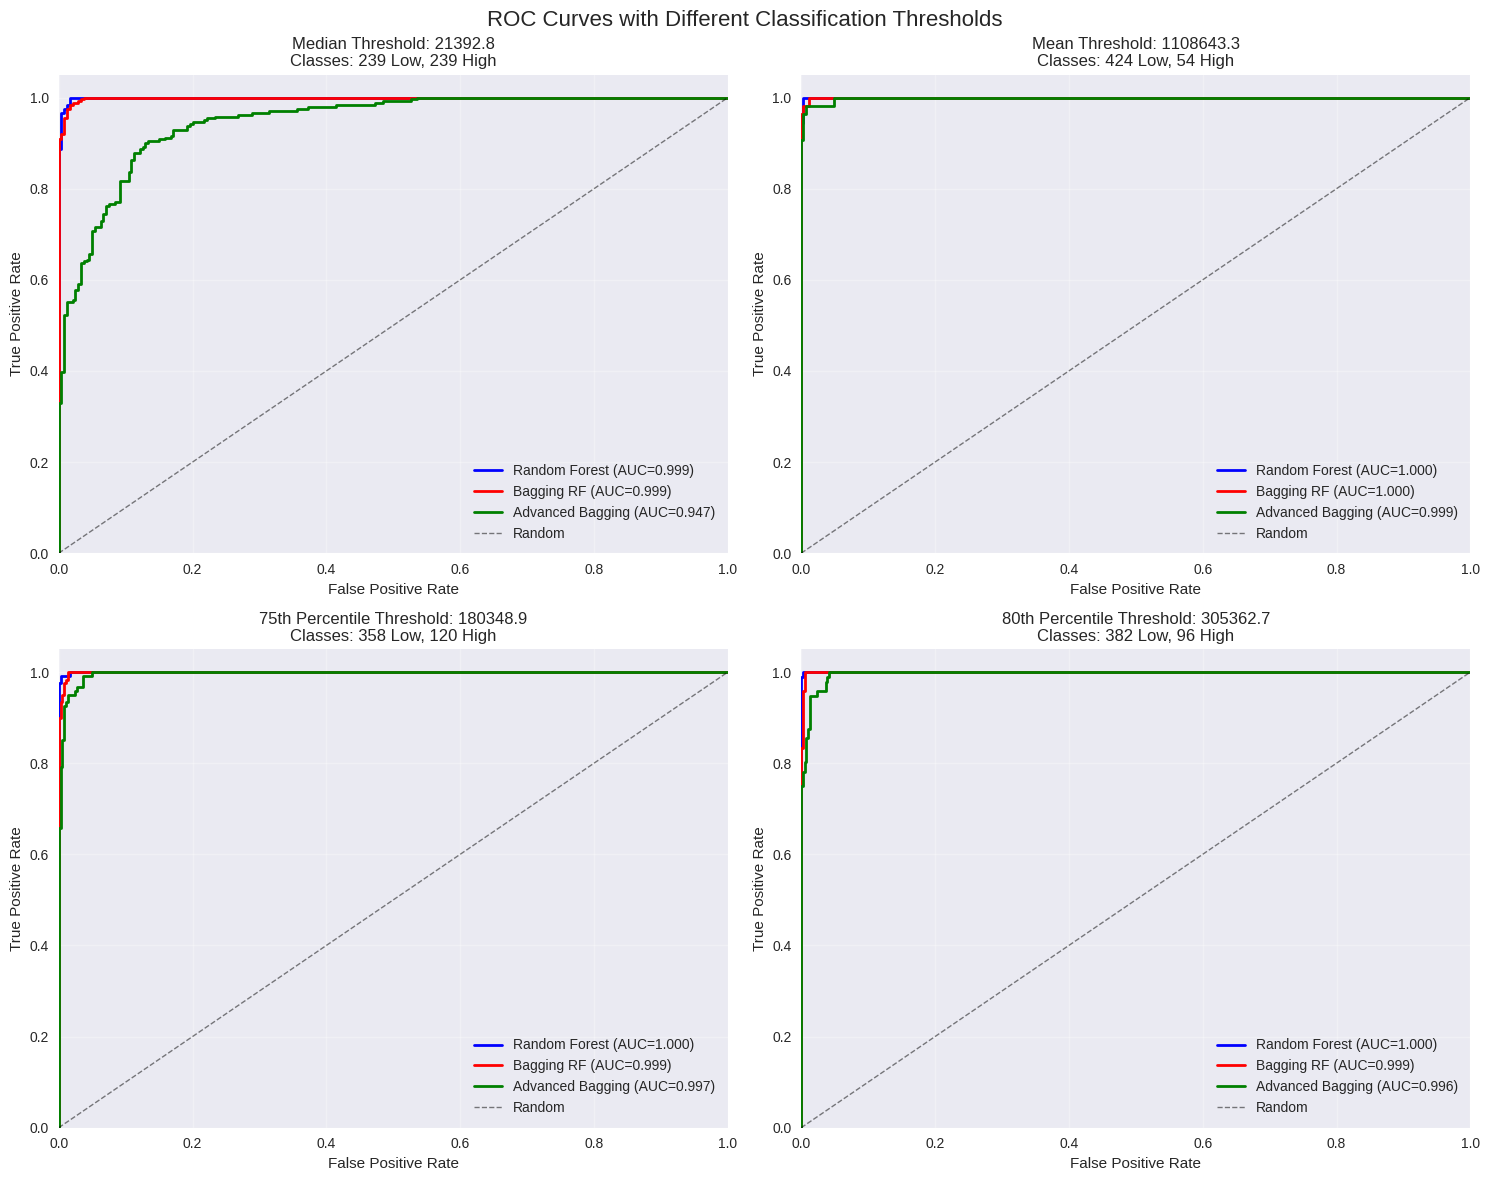

In [16]:
# CELL 15: Multi-threshold ROC Comparison and Advanced Analysis

def multi_threshold_roc_analysis(y_true, predictions_dict):
    """
    Analyze ROC curves with different threshold methods
    """
    print("=== Multi-Threshold ROC Analysis ===")

    threshold_methods = {
        'Median': np.median(y_true),
        'Mean': np.mean(y_true),
        '75th Percentile': np.quantile(y_true, 0.75),
        '80th Percentile': np.quantile(y_true, 0.80)
    }

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('ROC Curves with Different Classification Thresholds', fontsize=16)

    colors = ['blue', 'red', 'green']

    for idx, (threshold_name, threshold_val) in enumerate(threshold_methods.items()):
        row, col = idx // 2, idx % 2
        ax = axes[row, col]

        # Create binary labels for this threshold
        y_binary = (y_true > threshold_val).astype(int)
        class_counts = np.bincount(y_binary)

        # Plot ROC curves for all models with this threshold
        for i, (model_name, y_pred) in enumerate(predictions_dict.items()):
            fpr, tpr, _ = roc_curve(y_binary, y_pred)
            auc_score = roc_auc_score(y_binary, y_pred)

            ax.plot(fpr, tpr, color=colors[i], lw=2,
                   label=f'{model_name} (AUC={auc_score:.3f})')

        ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random')
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(f'{threshold_name} Threshold: {threshold_val:.1f}\n'
                    f'Classes: {class_counts[0]} Low, {class_counts[1]} High')
        ax.legend(loc="lower right", fontsize=10)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Generate multi-threshold analysis
multi_threshold_roc_analysis(y_test, predictions_dict)
